In [ ]:
import operator
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from pydantic import BaseModel
from typing import Annotated, Literal
from langchain_core.messages import SystemMessage, ToolMessage, HumanMessage, AIMessage
from langgraph.graph import StateGraph, add_messages, END
from langgraph.prebuilt import ToolNode
from langchain_core.tools import tool, InjectedToolCallId
from langgraph.checkpoint.memory import MemorySaver
from datetime import datetime
from multi_agent.session_code.researcher import graph as research_agent
from copywriter import graph as copywriter_agent
from langgraph.types import Command, RunnableConfig

load_dotenv()

supervisor_prompt = open("prompts/supervisor.md", "r").read()


class SupervisorState(BaseModel):
    """The state of the supervisor agent. 
    
    The research_reports attribute is shared with the researcher agent. This allows us to share the research reports between the researcher and copywriter agents.
    """
    messages: Annotated[list, add_messages] = []
    research_reports: Annotated[list, operator.add] = []
    task_description: str | None = None


@tool
async def handoff_to_subagent(
    agent_name: Literal["researcher", "copywriter"],
    task_description: str,
    tool_call_id: Annotated[str, InjectedToolCallId()],
    ):
    """Assign a task to a sub-agent: researcher or copywriter.
    
    Args:
        agent_name: The name of the agent to handoff the task to. Valid agent names are researcher and copywriter.
        task_description: The description of the task to be completed.
    """
    
    update = {
        "task_description": task_description,
        "messages": [ToolMessage(
            name=f"handoff_to_{agent_name}",
            content=f"Successfully handed off task to {agent_name}.",
            tool_call_id=tool_call_id,
        )],
        }

   
    return Command(
        goto=f"call_{agent_name}",
        update=update
        )


@tool
async def brave_search(
    query: str,
    tool_call_id: Annotated[str, InjectedToolCallId()],
):
    """Compatibility shim for accidental supervisor web-search calls.

    The supervisor does not search directly; route any search request to the
    researcher agent instead.
    """

    update = {
        "task_description": (
            "Research the following request using web search and produce a "
            f"cited research report: {query}"
        ),
        "messages": [ToolMessage(
            name="brave_search",
            content="Search request routed to researcher.",
            tool_call_id=tool_call_id,
        )],
    }

    return Command(
        goto="call_researcher",
        update=update,
    )


async def call_researcher(state: SupervisorState, config: RunnableConfig):
    """Call the researcher agent.
    
    The agent is invoked only with the task description generated by the supervisor, so the context window is not cluttered with the full conversation history of the supervisor.
    """
    research_response = await research_agent.ainvoke(
        input={
            "messages": [HumanMessage(content=state.task_description)],
            },
        config=config,
    )

    ai_message = AIMessage(name="researcher", content=research_response["messages"][-1].content)

    return {
        "research_reports": research_response["research_reports"],
        "messages": [ai_message],
        }

async def call_copywriter(state: SupervisorState, config: RunnableConfig):
    """Call the copywriter agent.
    
    The agent is invoked only with the task description generated by the supervisor, and any research reports that have been generated by the researcher.
    """
    copywriter_response = await copywriter_agent.ainvoke(
        input={
            "messages": [HumanMessage(content=state.task_description)],
            "research_reports": state.research_reports,
            },
        config=config,
        )
    
    ai_message = AIMessage(name="copywriter", content=copywriter_response["messages"][-1].content)

    return {"messages": [ai_message]}

llm = ChatGroq(
    name="Supervisor",
    model="llama-3.3-70b-versatile",
)

tools=[handoff_to_subagent, brave_search]
llm_with_tools = llm.bind_tools(tools, parallel_tool_calls=False)


async def supervisor(state: SupervisorState):
    """The main supervisor agent."""
    response = llm_with_tools.invoke([
        SystemMessage(content=supervisor_prompt.format(current_datetime=datetime.now()))
        ] + state.messages)
    return {"messages": [response]}

async def supervisor_router(state: SupervisorState) -> str:
    """Route to the tools node if the supervisor makes a tool call."""
    if state.messages[-1].tool_calls:
        return "tools"
    return END

builder = StateGraph(SupervisorState)

builder.add_node(
    supervisor,
    destinations=("tools", "call_researcher", "call_copywriter", END)
    )
builder.add_node("tools", ToolNode(tools))
builder.add_node(call_researcher)
builder.add_node(call_copywriter)

builder.set_entry_point("supervisor")

builder.add_edge("call_researcher", "supervisor")
builder.add_edge("call_copywriter", "supervisor")

supervisor_agent = builder.compile(checkpointer=MemorySaver())


In [ ]:
from copywriter import graph as copywriter_agent
from multi_agent.session_code.researcher import graph as researcher_agent
from multi_agent.session_code.supervisor import graph as supervisor_agent

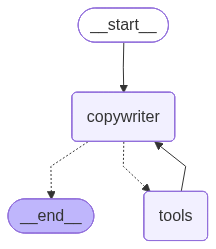

In [8]:
copywriter_agent

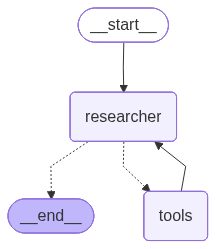

In [9]:
researcher_agent

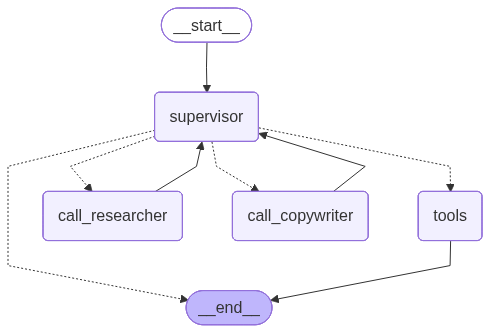

In [14]:
supervisor_agent